# Selectable DC4 point-source catalog generator

This notebook creates a fully fixed astromodels YAML catalog for an NGC 4151
fit. NGC 4151 is always included. Set `ADDITIONAL_SOURCE_NAMES` to the exact
name or names of the nuisance sources to include, rerun the notebook, and then
rerun `NGC4151_DC4_Spectral_Fit.ipynb`.

The available names are listed in approximate descending contribution in the
NGC 4151 60° FOV selection. Variable sources retain separate catalog entries
where separate light-curve-weighted responses are required.


In [1]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from astromodels import (
    Cutoff_powerlaw,
    Line,
    LinearPolarization,
    Log_parabola,
    Model,
    PointSource,
    Powerlaw,
    SpectralComponent,
    load_model,
)
from cosipy.threeml.custom_functions import SpecFromDat

%matplotlib inline


18:47:21 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=362260;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=781077;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=633761;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=471924;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=649856;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=982981;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

18:47:22 INFO      Starting 3ML!                                                                     ]8;id=352841;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=753594;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=466854;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=548751;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=523131;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=724838;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=440322;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=956545;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=732377;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=670028;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=628941;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=383896;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=704662;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=605554;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Locate the injected spectral tables

The tables are read directly from the local `cositools/cosi-sim` clone at `/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library`. The helper searches recursively below its `DC3/` and `DC4/` directories.

The catalog uses the following injected tables where a regular astromodels function is not a faithful representation:

- `cygX1_hard_0.1-0.4_spec.dat`
- `cygX1_hard_0.4-10_spec.dat`
- `GRS1758_spec.dat`
- `Crab_Ne_spec.dat`, `Crab_P1_spec.dat`, `Crab_Brg_spec.dat`, and `Crab_P2_spec.dat`
- `4C71p07_spectrum.dat`
- `4C_21_spectrum_noflare.dat` and `4C_21_spectrum_flare.dat`
- `MAXIJ1820_0.1-0.4_spec.dat` and `MAXIJ1820_0.4-10_spec.dat`
- `MAXIJ1348_0.1-0.4_spec.dat` and `MAXIJ1348_0.4-10_spec.dat`
- `3C454p3_low_spectrum.dat` and `3C454p3_high_spectrum.dat`
- `cygX3_transition_spec.dat`, `PSRB1259_spec.dat`, `LS5039_spec.dat`, and `J1846_spec.dat`
- `nova_co_continuum_spec.dat`

The individual simulated FITS source files in `DC4_Files/DC4_Sources` are event-data products and cannot replace these spectral `.dat` files.

In [2]:
SOURCE_DATA_ROOT = Path(
    "/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library"
)


def find_source_file(challenge, filename):
    """Find one source-library file below DC3/ or DC4/."""
    search_root = SOURCE_DATA_ROOT / challenge
    matches = sorted(search_root.rglob(filename))

    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename!r} below {search_root}. "
            "The simulated FITS source files are not spectral tables; copy the "
            "corresponding .dat file from the cosi-sim source library into this "
            "DC3/DC4 directory."
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Found more than one copy of {filename!r}: {matches}. "
            "Keep one copy or set the desired path explicitly."
        )

    return matches[0].resolve()


cygx1_low_path = find_source_file("DC3", "cygX1_hard_0.1-0.4_spec.dat")
cygx1_high_path = find_source_file("DC3", "cygX1_hard_0.4-10_spec.dat")
grs1758_path = find_source_file("DC3", "GRS1758_spec.dat")
crab_nebula_path = find_source_file("DC4", "Crab_Ne_spec.dat")
crab_p1_path = find_source_file("DC4", "Crab_P1_spec.dat")
crab_bridge_path = find_source_file("DC4", "Crab_Brg_spec.dat")
crab_p2_path = find_source_file("DC4", "Crab_P2_spec.dat")
four_c_71p07_path = find_source_file("DC4", "4C71p07_spectrum.dat")
four_c_21p35_noflare_path = find_source_file(
    "DC3", "4C_21_spectrum_noflare.dat"
)
four_c_21p35_flare_path = find_source_file(
    "DC3", "4C_21_spectrum_flare.dat"
)
maxi_j1820_low_path = find_source_file("DC3", "MAXIJ1820_0.1-0.4_spec.dat")
maxi_j1820_high_path = find_source_file("DC3", "MAXIJ1820_0.4-10_spec.dat")
maxi_j1348_low_path = find_source_file("DC3", "MAXIJ1348_0.1-0.4_spec.dat")
maxi_j1348_high_path = find_source_file("DC3", "MAXIJ1348_0.4-10_spec.dat")
three_c_454p3_low_path = find_source_file("DC4", "3C454p3_low_spectrum.dat")
three_c_454p3_high_path = find_source_file("DC4", "3C454p3_high_spectrum.dat")
cyg_x3_path = find_source_file("DC4", "cygX3_transition_spec.dat")
psr_b1259_path = find_source_file("DC3", "PSRB1259_spec.dat")
ls_5039_path = find_source_file("DC3", "LS5039_spec.dat")
psr_j1846_path = find_source_file("DC3", "J1846_spec.dat")
co_nova_continuum_path = find_source_file("DC3", "nova_co_continuum_spec.dat")

print("Cyg X-1 low-energy table:", cygx1_low_path)
print("Cyg X-1 high-energy table:", cygx1_high_path)
print("GRS 1758 table:", grs1758_path)
print("Crab tables:", crab_nebula_path, crab_p1_path, crab_bridge_path, crab_p2_path)
print("4C 71.07 table:", four_c_71p07_path)
print("4C 21.35 tables:", four_c_21p35_noflare_path, four_c_21p35_flare_path)
print("MAXI J1820 tables:", maxi_j1820_low_path, maxi_j1820_high_path)
print("MAXI J1348 tables:", maxi_j1348_low_path, maxi_j1348_high_path)
print("3C 454.3 tables:", three_c_454p3_low_path, three_c_454p3_high_path)
print("Cyg X-3 table:", cyg_x3_path)
print("PSR B1259 table:", psr_b1259_path)
print("LS 5039 table:", ls_5039_path)
print("PSR J1846 table:", psr_j1846_path)
print("CO nova continuum table:", co_nova_continuum_path)

Cyg X-1 low-energy table: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/cygX1_hard/cygX1_hard_0.1-0.4_spec.dat
Cyg X-1 high-energy table: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/cygX1_hard/cygX1_hard_0.4-10_spec.dat
GRS 1758 table: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/GRS1758/GRS1758_spec.dat
Crab tables: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_Ne_spec.dat /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_P1_spec.dat /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_Brg_spec.dat /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_P2_spec.dat
4C 71.07 table: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Extragalactic/4C71p07/4C71p07_spectrum.dat
4C 21.35 tables: /Users/parshadkp/Sof

## Table-spectrum helper

`SpecFromDat` preserves the tabulated shape and provides a normalization parameter. Its current normalization uses a simple bin-width sum, so the helper below performs a numerical correction such that the model integral from 100 keV to 10 MeV equals the injected source-file flux. Absolute paths are stored in the YAML so the model can be reloaded from another working directory. The normalization is fixed before serialization.

In [3]:
ENERGY_MIN = 100.0
ENERGY_MAX = 10_000.0
PHOTON_FLUX_UNIT = 1 / (u.cm**2 * u.s)
DIFFERENTIAL_FLUX_UNIT = 1 / (u.keV * u.cm**2 * u.s)


def table_spectrum(dat_path, injected_photon_flux):
    """Create a SpecFromDat component normalized to an integrated flux."""
    spectrum = SpecFromDat(
        K=float(injected_photon_flux),
        dat=Path(dat_path).resolve(),
    )

    energy = np.geomspace(ENERGY_MIN, ENERGY_MAX, 20_000)
    current_integral = np.trapezoid(spectrum(energy), energy)

    if not np.isfinite(current_integral) or current_integral <= 0:
        raise ValueError(f"Invalid spectrum integral for {dat_path}: {current_integral}")

    spectrum.K.value *= float(injected_photon_flux) / current_integral
    return spectrum


def normalize_analytic_components(components, injected_photon_flux):
    """Scale analytic component amplitudes to the injected integrated flux."""
    energy = np.geomspace(ENERGY_MIN, ENERGY_MAX, 20_000)
    current_integral = np.trapezoid(
        sum(component(energy) for component in components),
        energy,
    )

    if not np.isfinite(current_integral) or current_integral <= 0:
        raise ValueError(f"Invalid analytic spectrum integral: {current_integral}")

    scale = float(injected_photon_flux) / current_integral
    for component in components:
        component.K.value *= scale


def set_normalization_step(parameter):
    """Use a scale-appropriate initial optimizer step."""
    parameter.delta = max(abs(parameter.value) * 0.05, 1e-12)

## 1. Cyg X-1 hard state

The injected hard-state spectrum is an `eqpair` calculation divided into two energy ranges for the polarization simulation. Native astromodels does not provide this `eqpair` model, so the two injected tables are retained and their relative normalization is fixed.

In [4]:
cygx1_low_flux = 0.04243172227636306
cygx1_high_flux = 0.003371822180706115

cygx1_low = table_spectrum(cygx1_low_path, cygx1_low_flux)
cygx1_high = table_spectrum(cygx1_high_path, cygx1_high_flux)
cygx1_spectrum = cygx1_low + cygx1_high

cygx1 = PointSource(
    "cyg_x1_hard",
    l=71.33496,
    b=3.066917,
    spectral_shape=cygx1_spectrum,
)

## 2. Crab

The DC4 Crab is retained as four distinct astromodels spectral components:
nebula, peak 1, bridge, and peak 2. Each uses its exact injected table and
integrated flux. The nebula has 40% polarization at 160° and the three pulsar
components have 20% polarization at 145°, in Galactic/IAU coordinates.

The pulsar light curves repeat every 0.0333924123 s and are normalized to unit
mean by MEGAlib. Each 15 s spacecraft interval therefore averages over about
449 pulse periods, so the time-integrated response uses their mean spectra.
The catalog preserves the injected polarization metadata, but exact
polarized folding additionally requires a detector response with a `Pol` axis.
The current continuum response lacks that axis, so the fitting notebook reports
and uses an in-memory zero-polarization approximation.

Although `Crab.source` contains `EarthOccultation false`, transferring that flag
to the current binned response overpredicts the selected Crab counts by almost
an order of magnitude. The spectral fit therefore retains the response's
standard source-visibility treatment, which agrees with the selected DC4 Crab
events.


In [5]:
crab_nebula = table_spectrum(crab_nebula_path, 0.033197515)
crab_p1 = table_spectrum(crab_p1_path, 0.002380673782066656)
crab_bridge = table_spectrum(crab_bridge_path, 0.0006280494007254569)
crab_p2 = table_spectrum(crab_p2_path, 0.0032012384701172636)

crab_components = [
    SpectralComponent(
        "nebula",
        crab_nebula,
        LinearPolarization(40.0, 160.0),
    ),
    SpectralComponent(
        "peak1",
        crab_p1,
        LinearPolarization(20.0, 145.0),
    ),
    SpectralComponent(
        "bridge",
        crab_bridge,
        LinearPolarization(20.0, 145.0),
    ),
    SpectralComponent(
        "peak2",
        crab_p2,
        LinearPolarization(20.0, 145.0),
    ),
]

crab = PointSource(
    "crab",
    l=184.5575,
    b=-5.78434,
    components=crab_components,
)

for component in crab.components.values():
    component.polarization.degree.fix = True
    component.polarization.angle.fix = True


## 3. 1E 1740.7−2942

The injected `compow` table is accurately represented in the COSI energy range by a cutoff power law plus a high-energy power-law tail. Their relative normalization is linked, and the remaining overall amplitude is fixed before the catalog is saved.

In [6]:
one_e_thermal = Cutoff_powerlaw()
one_e_thermal.K.value = 7.871196815455384e-4
one_e_thermal.piv.value = 300.0
one_e_thermal.index.value = 0.4379077571700285
one_e_thermal.xc.value = 31.912756594453995

one_e_tail = Powerlaw()
one_e_tail.K.value = 3.929675541578979e-6
one_e_tail.piv.value = 300.0
one_e_tail.index.value = -1.8998638815533166

for spectrum in (one_e_thermal, one_e_tail):
    spectrum.K.unit = DIFFERENTIAL_FLUX_UNIT
    spectrum.piv.unit = u.keV

one_e_thermal.xc.unit = u.keV

for parameter in (
    one_e_thermal.piv,
    one_e_thermal.index,
    one_e_thermal.xc,
    one_e_tail.piv,
    one_e_tail.index,
):
    parameter.fix = True

one_e_spectrum = one_e_thermal + one_e_tail

one_e_1740 = PointSource(
    "one_e_1740_compow",
    l=359.11596,
    b=-0.10575,
    spectral_shape=one_e_spectrum,
)

## 4. GRS 1758−258

The injected spectrum is a thermal-Comptonization model. The original table is retained rather than replacing its curvature with a simple power law.

In [7]:
grs1758_flux = 0.003495
grs1758_spectrum = table_spectrum(grs1758_path, grs1758_flux)

grs1758 = PointSource(
    "grs_1758_258",
    l=4.50780,
    b=-1.36106,
    spectral_shape=grs1758_spectrum,
)

## 5. Cen A

Cen A is injected as a power law with photon index −1.732 and integrated 100 keV–10 MeV flux 0.00197 ph cm$^{-2}$ s$^{-1}$.

In [8]:
cena_spectrum = Powerlaw()
cena_spectrum.K.value = 2.227338148135328e-6
cena_spectrum.piv.value = 300.0
cena_spectrum.index.value = -1.732

cena_spectrum.K.unit = DIFFERENTIAL_FLUX_UNIT
cena_spectrum.piv.unit = u.keV
cena_spectrum.piv.fix = True
cena_spectrum.index.fix = True
cena = PointSource(
    "cena",
    l=309.516,
    b=19.417,
    spectral_shape=cena_spectrum,
)

## 6. 4C 71.07

4C 71.07 retains its injected tabulated spectrum and is treated as steady.

In [9]:
four_c_71p07_spectrum = table_spectrum(four_c_71p07_path, 0.00119)
four_c_71p07 = PointSource(
    "four_c_71p07",
    l=143.540759,
    b=34.425671,
    spectral_shape=four_c_71p07_spectrum,
)

## 7. 4C 21.35

The non-flare and flare spectra are separate catalog entries. Each must use its corresponding light-curve-weighted response rather than being interpreted as a steady source.

In [10]:
four_c_21p35_noflare_spectrum = table_spectrum(
    four_c_21p35_noflare_path,
    0.0005535,
)
four_c_21p35_noflare = PointSource(
    "four_c_21p35_noflare",
    l=255.073637,
    b=81.659766,
    spectral_shape=four_c_21p35_noflare_spectrum,
)

four_c_21p35_flare_spectrum = table_spectrum(
    four_c_21p35_flare_path,
    0.017293201590129727,
)
four_c_21p35_flare = PointSource(
    "four_c_21p35_flare",
    l=255.073637,
    b=81.659766,
    spectral_shape=four_c_21p35_flare_spectrum,
)

## 8. MAXI J1820

The two injected tabulated components share one outburst light curve and one linked catalog amplitude.

In [11]:
maxi_j1820_low = table_spectrum(
    maxi_j1820_low_path,
    0.13820979415525897,
)
maxi_j1820_high = table_spectrum(
    maxi_j1820_high_path,
    0.005963517352694539,
)
maxi_j1820 = PointSource(
    "maxi_j1820",
    l=35.8535,
    b=10.15915,
    spectral_shape=maxi_j1820_low + maxi_j1820_high,
)

## 9. MAXI J1348−630

The two injected tabulated components share one outburst light curve and one linked catalog amplitude.

In [12]:
maxi_j1348_low = table_spectrum(
    maxi_j1348_low_path,
    0.08633295828868433,
)
maxi_j1348_high = table_spectrum(
    maxi_j1348_high_path,
    0.0023113717669982913,
)
maxi_j1348 = PointSource(
    "maxi_j1348",
    l=309.26389732,
    b=-1.10328,
    spectral_shape=maxi_j1348_low + maxi_j1348_high,
)

## 10. 3C 454.3

The low and high states are separate tabulated catalog entries and require their corresponding time-weighted responses.

In [13]:
three_c_454p3_low = PointSource(
    "three_c_454p3_low",
    l=86.111069,
    b=-38.183817,
    spectral_shape=table_spectrum(three_c_454p3_low_path, 0.00029),
)
three_c_454p3_high = PointSource(
    "three_c_454p3_high",
    l=86.111069,
    b=-38.183817,
    spectral_shape=table_spectrum(three_c_454p3_high_path, 0.00624),
)

## 11. NGC 1068

NGC 1068 uses its injected cutoff-power-law plus high-energy power-law tail. The components are normalized to the injected 100 keV–10 MeV photon flux and linked at their injected ratio.

In [14]:
ngc1068_thermal = Cutoff_powerlaw()
ngc1068_thermal.K.value = 0.308 * 200.0**-1.92
ngc1068_thermal.piv.value = 200.0
ngc1068_thermal.index.value = -1.92
ngc1068_thermal.xc.value = 200.0
ngc1068_tail = Powerlaw()
ngc1068_tail.K.value = 91.18 * 200.0**-3.8
ngc1068_tail.piv.value = 200.0
ngc1068_tail.index.value = -3.8

for component in (ngc1068_thermal, ngc1068_tail):
    component.K.unit = DIFFERENTIAL_FLUX_UNIT
    component.piv.unit = u.keV
    component.piv.fix = True
    component.index.fix = True

ngc1068_thermal.xc.unit = u.keV
ngc1068_thermal.xc.fix = True
normalize_analytic_components((ngc1068_thermal, ngc1068_tail), 0.00161)

ngc1068 = PointSource(
    "ngc1068",
    l=172.103584,
    b=-51.933771,
    spectral_shape=ngc1068_thermal + ngc1068_tail,
)

## 12. NGC 4151

This is the updated mock-data injection from `AGN_Corona_DC4.ipynb`: a cutoff power law with `K = 0.15` at 1 keV, index −1.75, and cutoff 200 keV, plus an index −3.8 power-law tail whose differential flux at 200 keV is 30% of the thermal flux. The implementation is pivoted at 200 keV without changing the injected spectrum.

In [15]:
ngc4151_thermal = Cutoff_powerlaw()
ngc4151_thermal.K.value = 0.15 * 200.0**-1.75
ngc4151_thermal.piv.value = 200.0
ngc4151_thermal.index.value = -1.75
ngc4151_thermal.xc.value = 200.0
ngc4151_tail = Powerlaw()
ngc4151_tail_fraction_at_200kev = 0.30
ngc4151_tail.K.value = (
    ngc4151_tail_fraction_at_200kev
    * ngc4151_thermal.evaluate_at(200.0)
)
ngc4151_tail.piv.value = 200.0
ngc4151_tail.index.value = -3.8

for component in (ngc4151_thermal, ngc4151_tail):
    component.K.unit = DIFFERENTIAL_FLUX_UNIT
    component.piv.unit = u.keV
    component.piv.fix = True
    component.index.fix = True

ngc4151_thermal.xc.unit = u.keV
ngc4151_thermal.xc.fix = True
assert np.isclose(
    ngc4151_tail.evaluate_at(200.0)
    / ngc4151_thermal.evaluate_at(200.0),
    ngc4151_tail_fraction_at_200kev,
)

ngc4151_energy = np.geomspace(ENERGY_MIN, ENERGY_MAX, 20_000)
ngc4151_injected_flux = np.trapezoid(
    (ngc4151_thermal + ngc4151_tail)(ngc4151_energy),
    ngc4151_energy,
)
assert np.isclose(ngc4151_injected_flux, 0.0025171894, rtol=1e-5)

ngc4151 = PointSource(
    "ngc4151",
    l=155.077404,
    b=75.063170,
    spectral_shape=ngc4151_thermal + ngc4151_tail,
)

## 13. Cyg X-3

The injected transition-state spectrum is retained as a tabulated model.

In [16]:
cyg_x3 = PointSource(
    "cyg_x3",
    l=79.84549,
    b=0.70006,
    spectral_shape=table_spectrum(cyg_x3_path, 0.001331405),
)

## 14. PSR B1259−63

The injected table defines the spectral shape; its light curve must be included through a time-weighted response.

In [17]:
psr_b1259 = PointSource(
    "psr_b1259",
    l=304.18358257,
    b=-0.99158457,
    spectral_shape=table_spectrum(psr_b1259_path, 0.00061253),
)

## 15. 1RXS J170849.0−400901

The injected magnetar continuum is represented directly with a fixed astromodels `Log_parabola`.

In [18]:
one_rxs_j170849_spectrum = Log_parabola()
one_rxs_j170849_spectrum.K.value = 1.68e-6
one_rxs_j170849_spectrum.piv.value = 143.276
one_rxs_j170849_spectrum.alpha.value = -1.637
one_rxs_j170849_spectrum.beta.value = 0.261
one_rxs_j170849_spectrum.K.unit = DIFFERENTIAL_FLUX_UNIT
one_rxs_j170849_spectrum.piv.unit = u.keV
one_rxs_j170849_spectrum.piv.fix = True
one_rxs_j170849_spectrum.alpha.fix = True
one_rxs_j170849_spectrum.beta.fix = True
normalize_analytic_components((one_rxs_j170849_spectrum,), 0.00033)
one_rxs_j170849 = PointSource(
    "one_rxs_j170849",
    l=346.47938142,
    b=0.03838608,
    spectral_shape=one_rxs_j170849_spectrum,
)

## 16. Generic magnetar

The generic magnetar uses the injected fixed `Log_parabola`, with twice the curvature parameter of the 1RXS J170849.0−400901 model.

In [19]:
generic_magnetar_spectrum = Log_parabola()
generic_magnetar_spectrum.K.value = 1.68e-6
generic_magnetar_spectrum.piv.value = 143.276
generic_magnetar_spectrum.alpha.value = -1.637
generic_magnetar_spectrum.beta.value = 0.522
generic_magnetar_spectrum.K.unit = DIFFERENTIAL_FLUX_UNIT
generic_magnetar_spectrum.piv.unit = u.keV
generic_magnetar_spectrum.piv.fix = True
generic_magnetar_spectrum.alpha.fix = True
generic_magnetar_spectrum.beta.fix = True
normalize_analytic_components((generic_magnetar_spectrum,), 0.00033)

generic_magnetar = PointSource(
    "generic_magnetar",
    l=250.0,
    b=0.03838608,
    spectral_shape=generic_magnetar_spectrum,
)

## 17. LS 5039

The injected table defines the spectral shape; the periodic light curve must be included through a time-weighted response.

In [20]:
ls_5039 = PointSource(
    "ls_5039",
    l=16.88158741,
    b=-1.28921165,
    spectral_shape=table_spectrum(ls_5039_path, 0.0003006),
)

## 18. PSR J1846−0258

The injected table defines the spectral shape; the phase light curve must be included through a time-weighted response.

In [21]:
psr_j1846 = PointSource(
    "psr_j1846",
    l=29.71195,
    b=-0.24012,
    spectral_shape=table_spectrum(psr_j1846_path, 0.000152392),
)

## 19. CO nova continuum

Only the continuum component is included here. Its tabulated peak spectrum must be combined with the injected nova light curve through a time-weighted response.

In [22]:
co_nova_continuum = PointSource(
    "co_nova_continuum",
    l=310.9847,
    b=2.7256,
    spectral_shape=table_spectrum(co_nova_continuum_path, 0.122071),
)

## Choose sources by name

NGC 4151 is always the fit target. Set `ADDITIONAL_SOURCE_NAMES = []` for an
NGC-4151-only catalog, or enter one or more exact names, for example:

```python
ADDITIONAL_SOURCE_NAMES = ["crab"]
ADDITIONAL_SOURCE_NAMES = ["crab", "cena", "ngc1068"]
```

The output filename stays `source_catalog_DC4.yaml`, so the fitting notebook
automatically uses the latest selection. The two states of 4C 21.35 and
3C 454.3 are separate entries because each state has a different injected
spectrum and light curve.


In [23]:
# Enter the exact nuisance-source names to include. NGC 4151 is automatic.
# Examples: ["crab"] or ["crab", "cena", "ngc1068"].
ADDITIONAL_SOURCE_NAMES = [
    "four_c_21p35_flare",
    "maxi_j1820",
    "maxi_j1348",
    "four_c_71p07",
    "four_c_21p35_noflare",
    "cena",
    "cyg_x1_hard",
    "one_e_1740_compow",
    "generic_magnetar",
    "psr_b1259",
    "grs_1758_258",
    "ls_5039",
    "one_rxs_j170849",
    "ngc1068",
    "cyg_x3",
    "psr_j1846",
    "three_c_454p3_low",
    "three_c_454p3_high",
    "co_nova_continuum",]

# Valid names, ordered by approximate contribution in the NGC 4151 FOV.
AVAILABLE_SOURCE_NAMES = [
    "crab",
    "four_c_21p35_flare",
    "maxi_j1820",
    "maxi_j1348",
    "four_c_71p07",
    "four_c_21p35_noflare",
    "cena",
    "cyg_x1_hard",
    "one_e_1740_compow",
    "generic_magnetar",
    "psr_b1259",
    "grs_1758_258",
    "ls_5039",
    "one_rxs_j170849",
    "ngc1068",
    "cyg_x3",
    "psr_j1846",
    "three_c_454p3_low",
    "three_c_454p3_high",
    "co_nova_continuum",
]

all_catalog_sources = {
    "cyg_x1_hard": cygx1,
    "crab": crab,
    "one_e_1740_compow": one_e_1740,
    "grs_1758_258": grs1758,
    "cena": cena,
    "four_c_71p07": four_c_71p07,
    "four_c_21p35_noflare": four_c_21p35_noflare,
    "four_c_21p35_flare": four_c_21p35_flare,
    "maxi_j1820": maxi_j1820,
    "maxi_j1348": maxi_j1348,
    "three_c_454p3_low": three_c_454p3_low,
    "three_c_454p3_high": three_c_454p3_high,
    "ngc1068": ngc1068,
    "ngc4151": ngc4151,
    "cyg_x3": cyg_x3,
    "psr_b1259": psr_b1259,
    "one_rxs_j170849": one_rxs_j170849,
    "generic_magnetar": generic_magnetar,
    "ls_5039": ls_5039,
    "psr_j1846": psr_j1846,
    "co_nova_continuum": co_nova_continuum,
}

if set(AVAILABLE_SOURCE_NAMES) != set(all_catalog_sources) - {"ngc4151"}:
    raise RuntimeError(
        "AVAILABLE_SOURCE_NAMES does not contain every nuisance entry"
    )

if isinstance(ADDITIONAL_SOURCE_NAMES, str):
    requested_source_names = [ADDITIONAL_SOURCE_NAMES]
else:
    requested_source_names = list(ADDITIONAL_SOURCE_NAMES)

if "ngc4151" in requested_source_names:
    raise ValueError(
        "Do not include 'ngc4151' in ADDITIONAL_SOURCE_NAMES; "
        "the target is included automatically."
    )

duplicate_source_names = sorted(
    {
        name
        for name in requested_source_names
        if requested_source_names.count(name) > 1
    }
)
if duplicate_source_names:
    raise ValueError(
        "Duplicate names in ADDITIONAL_SOURCE_NAMES: "
        + ", ".join(duplicate_source_names)
    )

unknown_source_names = sorted(
    set(requested_source_names) - set(AVAILABLE_SOURCE_NAMES)
)
if unknown_source_names:
    raise ValueError(
        "Unknown source name(s): "
        + ", ".join(unknown_source_names)
        + ". Valid names are: "
        + ", ".join(AVAILABLE_SOURCE_NAMES)
    )

selected_source_names = ["ngc4151", *requested_source_names]
model = Model(*(all_catalog_sources[name] for name in selected_source_names))


def link_at_current_ratio(dependent, independent):
    relation = Line(a=0.0, b=dependent.value / independent.value)
    relation.a.fix = True
    relation.b.fix = True
    model.link(dependent, independent, relation)


if "cyg_x1_hard" in model.sources:
    link_at_current_ratio(
        model.cyg_x1_hard.spectrum.main.composite.K_2,
        model.cyg_x1_hard.spectrum.main.composite.K_1,
    )

if "crab" in model.sources:
    crab_nebula_k = model["crab.spectrum.nebula.SpecFromDat.K"]
    for component_name in ("peak1", "bridge", "peak2"):
        link_at_current_ratio(
            model[f"crab.spectrum.{component_name}.SpecFromDat.K"],
            crab_nebula_k,
        )

if "one_e_1740_compow" in model.sources:
    link_at_current_ratio(
        model.one_e_1740_compow.spectrum.main.composite.K_2,
        model.one_e_1740_compow.spectrum.main.composite.K_1,
    )

if "maxi_j1820" in model.sources:
    link_at_current_ratio(
        model.maxi_j1820.spectrum.main.composite.K_2,
        model.maxi_j1820.spectrum.main.composite.K_1,
    )

if "maxi_j1348" in model.sources:
    link_at_current_ratio(
        model.maxi_j1348.spectrum.main.composite.K_2,
        model.maxi_j1348.spectrum.main.composite.K_1,
    )

if "ngc1068" in model.sources:
    link_at_current_ratio(
        model.ngc1068.spectrum.main.composite.K_2,
        model.ngc1068.spectrum.main.composite.K_1,
    )

link_at_current_ratio(
    model.ngc4151.spectrum.main.composite.K_2,
    model.ngc4151.spectrum.main.composite.K_1,
)

for parameter in model.free_parameters.values():
    set_normalization_step(parameter)

assert len(model.free_parameters) == len(model.sources)
print(
    f"Catalog includes {len(requested_source_names)} explicitly selected "
    "nuisance source entries."
)
print("Catalog sources:")
for source_name in model.sources:
    print(f"  {source_name}")


Catalog includes 19 explicitly selected nuisance source entries.
Catalog sources:
  ngc4151
  four_c_21p35_flare
  maxi_j1820
  maxi_j1348
  four_c_71p07
  four_c_21p35_noflare
  cena
  cyg_x1_hard
  one_e_1740_compow
  generic_magnetar
  psr_b1259
  grs_1758_258
  ls_5039
  one_rxs_j170849
  ngc1068
  cyg_x3
  psr_j1846
  three_c_454p3_low
  three_c_454p3_high
  co_nova_continuum


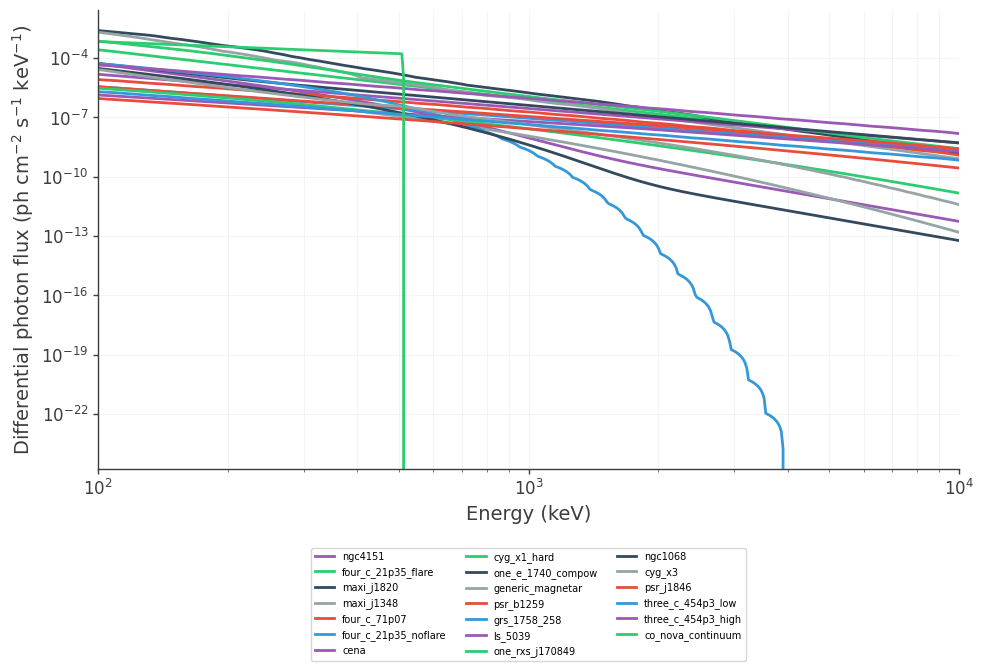

In [24]:
energy = np.geomspace(ENERGY_MIN, ENERGY_MAX, 500)

fig, ax = plt.subplots(figsize=(10, 7))
for source_name, source in model.sources.items():
    ax.loglog(energy, source(energy), label=source_name)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"Differential photon flux (ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$)")
ax.set_xlim(ENERGY_MIN, ENERGY_MAX)
ax.legend(
    fontsize=7,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
)
ax.grid(alpha=0.25, which="both")
fig.tight_layout()
plt.show()

In [25]:
catalog_path = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/"
    "continuum_fit/AGN/source_catalog_DC4.yaml"
)

for parameter in list(model.free_parameters.values()):
    parameter.fix = True

assert len(model.free_parameters) == 0

model.save(catalog_path, overwrite=True)
print(
    f"Saved fixed {len(model.sources)}-entry catalog "
    f"({len(requested_source_names)} nuisance entries): {catalog_path}"
)


Saved fixed 20-entry catalog (19 nuisance entries): /Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN/source_catalog_DC4.yaml


## Reload check

Import `SpecFromDat` before calling `load_model` in a fresh spectral-analysis process. The import registers the custom function used by the catalog's injected table components.

In [26]:
# Required in any fresh process before load_model:
from cosipy.threeml.custom_functions import SpecFromDat  # noqa: F401, E402

reloaded_model = load_model(catalog_path)

assert list(reloaded_model.sources) == selected_source_names
assert len(reloaded_model.free_parameters) == 0

print("Reloaded sources:", list(reloaded_model.sources))
print("Reloaded free parameters:", list(reloaded_model.free_parameters))
print("All catalog parameters are fixed.")


Reloaded sources: ['ngc4151', 'four_c_21p35_flare', 'maxi_j1820', 'maxi_j1348', 'four_c_71p07', 'four_c_21p35_noflare', 'cena', 'cyg_x1_hard', 'one_e_1740_compow', 'generic_magnetar', 'psr_b1259', 'grs_1758_258', 'ls_5039', 'one_rxs_j170849', 'ngc1068', 'cyg_x3', 'psr_j1846', 'three_c_454p3_low', 'three_c_454p3_high', 'co_nova_continuum']
Reloaded free parameters: []
All catalog parameters are fixed.


## Run the selected-source fit

Open `NGC4151_DC4_Spectral_Fit.ipynb` after this notebook finishes. It loads
the newly written catalog, constructs time-weighted responses only for the
variable sources in `ADDITIONAL_SOURCE_NAMES`, and frees the same four
NGC 4151 parameters each time.

To test a different catalog, return here, edit `ADDITIONAL_SOURCE_NAMES`, and
rerun all cells. Do not manually free nuisance-source parameters in the
generator; the YAML remains a fixed baseline catalog.


### Selection workflow

1. Set `ADDITIONAL_SOURCE_NAMES` to the exact nuisance source name or names.
2. Run this notebook from the top to rewrite `source_catalog_DC4.yaml`.
3. Run `NGC4151_DC4_Spectral_Fit.ipynb` and record the fit result.
4. Return here and change the name list for the next comparison.

Use `ADDITIONAL_SOURCE_NAMES = []` for an NGC-4151-only catalog. The generator
never frees fit parameters. The fitting notebook always starts from the newly
generated fixed YAML and explicitly frees only the four NGC 4151 parameters
used in the current analysis.
